# CellposeTraining Test Notebook

This notebook demonstrates the Cellpose training workflow using the **tough_cellpose** test project:

1. **Setup** — point to the tough_cellpose project (labels already exist)
2. **Generate patches from labels** — augment saved label crops into training patches
3. **Train** — train a Cellpose model on the patches
4. **Predict** — run the trained model on a test image
5. **Visualise** — compare input, ground truth, and prediction

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

from napari_ai_lab.Augmenters.albumentations_augmenter import (
    AlbumentationsAugmenter,
)
from napari_ai_lab.models.image_data_model import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.CellposeSegmenter import (
    CellposeSegmenter,
)

c:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\pixi\microsam_cellposesam_czi\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Setup Project

The tough_cellpose project already has saved label crops in `labels/input0` and `labels/truth0`.

In [2]:
# Use relative path from notebook location to test images
project_path = Path("../tests/test_images/tough_cellpose").resolve()

image_data_model = ImageDataModel(str(project_path))

print(f"Project: {project_path}")
print(f"Images found: {image_data_model.get_image_count()}")
print(f"Labels dir: {image_data_model.get_labels_directory()}")
print(f"Label crops (input0): {list(image_data_model.get_labels_directory().glob('input0/*.tif'))}")

Project: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\tough_cellpose
Images found: 143
Labels dir: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\tough_cellpose\labels
Label crops (input0): [WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img101_00000.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img101_00001.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img101_00002.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img101_00003.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img101_00004.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/tough_cellpose/labels/input0/img10

## 3. Delete Old Patches and Generate New Patches from Labels

We use the `from_label_boxes` workflow: the augmenter reads label crops from disk and generates augmented training patches.

In [5]:
# Delete old patches
image_data_model.delete_patches(axis="yx")

# Create augmenter and configure patch generation
#augmenter = SimpleAugmenter()
augmenter = AlbumentationsAugmenter()
image_data_model.set_augmenter(augmenter)
image_data_model.set_patch_size((256, 256))
image_data_model.set_num_patches(20)

# Generate patches from the saved label crops
patches_dir = image_data_model.generate_patches_from_labels() #axis="yx", axes_string="YX")

print(f"\nPatches directory: {patches_dir}")
print(f"Input patches: {len(list(Path(patches_dir, 'input0').glob('*.tif')))}")
print(f"Truth patches: {len(list(Path(patches_dir, 'ground_truth0').glob('*.tif')))}")

🎨 Generating 20 patches × 12 label crop(s) = 240 total...
Computed global normalization stats: low=0.0000, high=24929.0000
  Generating patches for img101_00000.tif (10/240)
  Generating patches for img101_00000.tif (20/240)
Computed global normalization stats: low=257.0000, high=31097.0000
  Generating patches for img101_00001.tif (30/240)
  Generating patches for img101_00001.tif (40/240)
Computed global normalization stats: low=257.0000, high=35209.0000
  Generating patches for img101_00002.tif (50/240)
  Generating patches for img101_00002.tif (60/240)
Computed global normalization stats: low=0.0000, high=25957.0000
  Generating patches for img101_00003.tif (70/240)
  Generating patches for img101_00003.tif (80/240)
Computed global normalization stats: low=0.0000, high=23387.0000
  Generating patches for img101_00004.tif (90/240)
  Generating patches for img101_00004.tif (100/240)
Computed global normalization stats: low=0.0000, high=36237.0000
  Generating patches for img101_00005

## 4. Visualise a Few Patches

Quick sanity check — display some input/truth patch pairs.

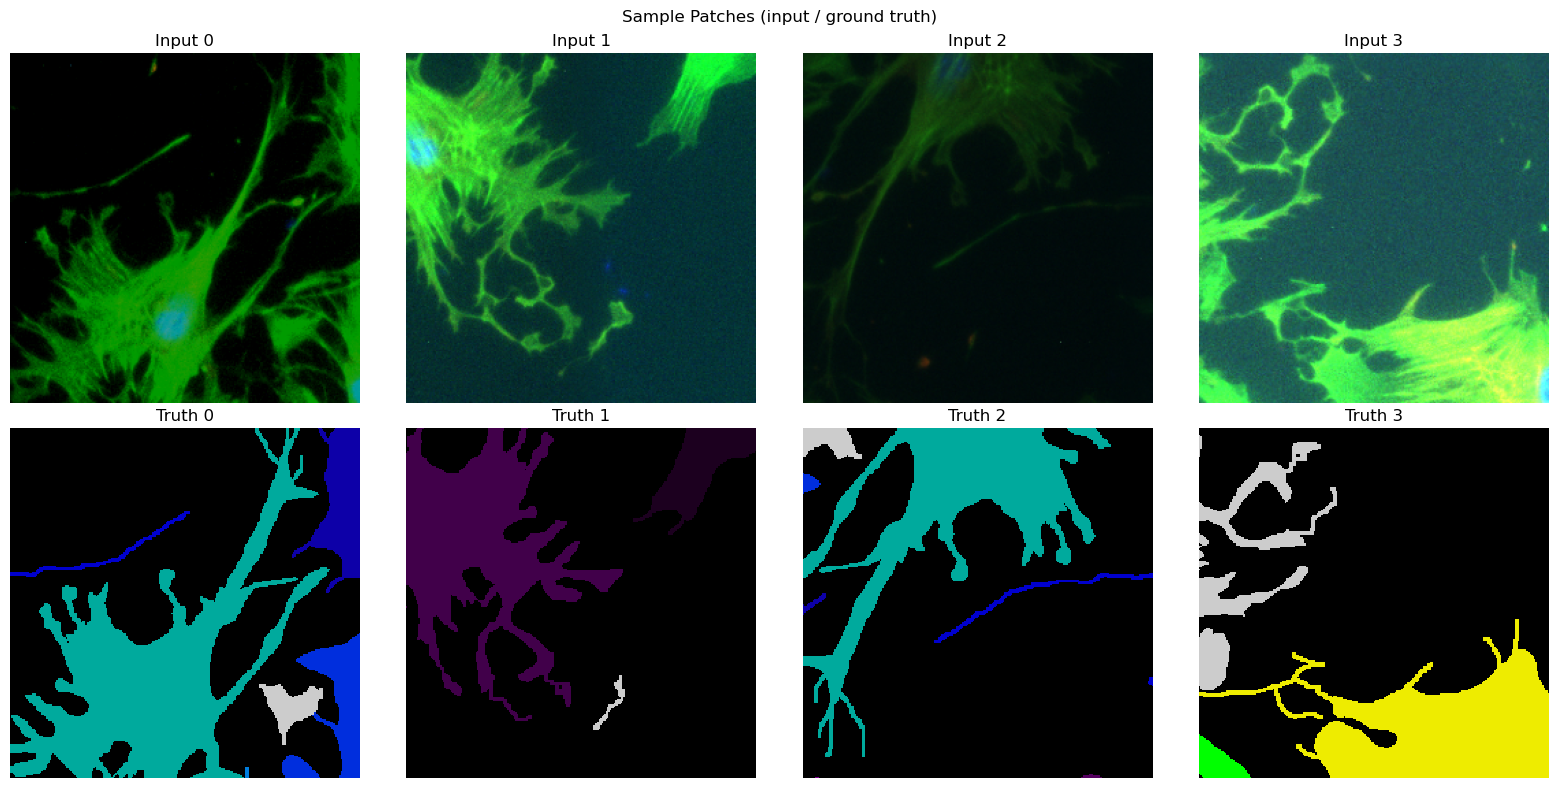

In [6]:
input_patches = sorted(Path(patches_dir, "input0").glob("*.tif"))
truth_patches = sorted(Path(patches_dir, "ground_truth0").glob("*.tif"))

n_show = min(4, len(input_patches))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for i in range(n_show):
    inp = tifffile.imread(str(input_patches[i]))
    gt = tifffile.imread(str(truth_patches[i]))

    axes[0, i].imshow(inp, cmap="gray")
    axes[0, i].set_title(f"Input {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt, cmap="nipy_spectral", interpolation="nearest")
    axes[1, i].set_title(f"Truth {i}")
    axes[1, i].axis("off")

plt.suptitle("Sample Patches (input / ground truth)")
plt.tight_layout()
plt.show()

## 5. Train Cellpose Model

Create a `CellposeSegmenter`, set training hyper-parameters, and call `train()`.

In [7]:
segmenter = CellposeSegmenter()

# Training hyper-parameters (kept small for a quick test)
segmenter.num_epochs = 10
segmenter.steps_per_epoch = 50
segmenter.train_patch_size_y = 256
segmenter.train_patch_size_x = 256

# Set paths on segmenter (same as _run_training does in the GUI)
segmenter.patch_path = str(patches_dir)
segmenter.model_name = "cellpose_nuclei_test"
segmenter.training_model_name = segmenter.model_name
segmenter.model_save_dir = str(project_path / "models")

model_name = segmenter.model_name
model_base_path = segmenter.model_save_dir

print(f"Patch path:  {segmenter.patch_path}")
print(f"Model name:  {model_name}")
print(f"Model base:  {model_base_path}")

Patch path:  C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\tough_cellpose\patches\patches_axis_yxc
Model name:  cellpose_nuclei_test
Model base:  C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\tough_cellpose\models


In [8]:
# Run training (same signature as MonaiUNetSegmenter.train)
result = segmenter.train()
print(result)

# Extract history object for plotting
training_history = result.get("history")
print(f"\nTraining history captured: {training_history is not None}")

0it [00:00, ?it/s]C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\src\napari_ai_lab\utilities\dl_util.py:117: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  x = io.imread(os.path.join(input_dir, input_name), plugin="tifffile")
C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\src\napari_ai_lab\utilities\dl_util.py:118: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  y = io.imread(os.path.join(truth_dir, truth_name), plugin="tifffile")
C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\src\na

🏋️ Training Cellpose v4.0.8: 238 train, 2 test
   axes=YXC, n_channel_in=3
   epochs=10, batch_size=8
   learning_rate=0.0001, weight_decay=0.0001
Training Cellpose model (version 4.x) with 238 training images...


  0%|          | 0/238 [00:00<?, ?it/s]c:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\pixi\microsam_cellposesam_czi\.pixi\envs\default\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\pixi\microsam_cellposesam_czi\.pixi\envs\default\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 2/2 [00:00<00:00, 1979.85it/s]


✅ Training complete. Model saved to: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\tough_cellpose\models\cellpose_nuclei_test
{'success': True, 'message': '✅ Training complete. Model saved to: C:\\Users\\bnort\\work\\ImageJ2022\\tnia\\napari-ai-lab\\tests\\test_images\\tough_cellpose\\models\\cellpose_nuclei_test'}

Training history captured: False


## 6. Plot Training Loss

Convert the Keras History object to a DataFrame and visualize the training curves.

In [9]:
import pandas as pd

# Convert history object to DataFrame (compatible with CSV format)
if training_history is not None:
    # history.history is a dict like {'loss': [...], 'val_loss': [...]}
    history_dict = training_history.history

    # Create DataFrame with epoch numbers
    df = pd.DataFrame({
        'epoch': range(len(history_dict.get('loss', []))),
        'loss': history_dict.get('loss', []),
        'val_loss': history_dict.get('val_loss', [])
    })

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(df["epoch"], df["loss"], label="train loss")
    if "val_loss" in df.columns and df["val_loss"].notna().any():
        ax.plot(df["epoch"], df["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("StarDist Training Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nTraining summary:")
    print(df.to_string(index=False))
else:
    print("No training history available. Run the training cell first.")

No training history available. Run the training cell first.


## 7. Predict on a Test Image

Load one of the nuclei images and run the trained model via `segmenter.segment()`.

In [16]:
# Load a test image from the project
test_images = sorted(project_path.glob("*.tif"))
test_image = tifffile.imread(str(test_images[1]))
print(f"Test image: {test_images[0].name}, shape={test_image.shape}, dtype={test_image.dtype}")

# The trained model is already on segmenter.custom_model after train()
predicted_labels = segmenter.segment(test_image)
print(f"Predicted labels: shape={predicted_labels.shape}, unique={len(np.unique(predicted_labels)) - 1} objects")

model_type argument is not used in v4.0.1+. Ignoring this argument...


Test image: img101.tif, shape=(747, 756, 3), dtype=uint16
Predicted labels: shape=(747, 756), unique=23 objects


## 8. Visualise Prediction

Side-by-side comparison of input, ground truth annotation (if available), and the StarDist prediction.

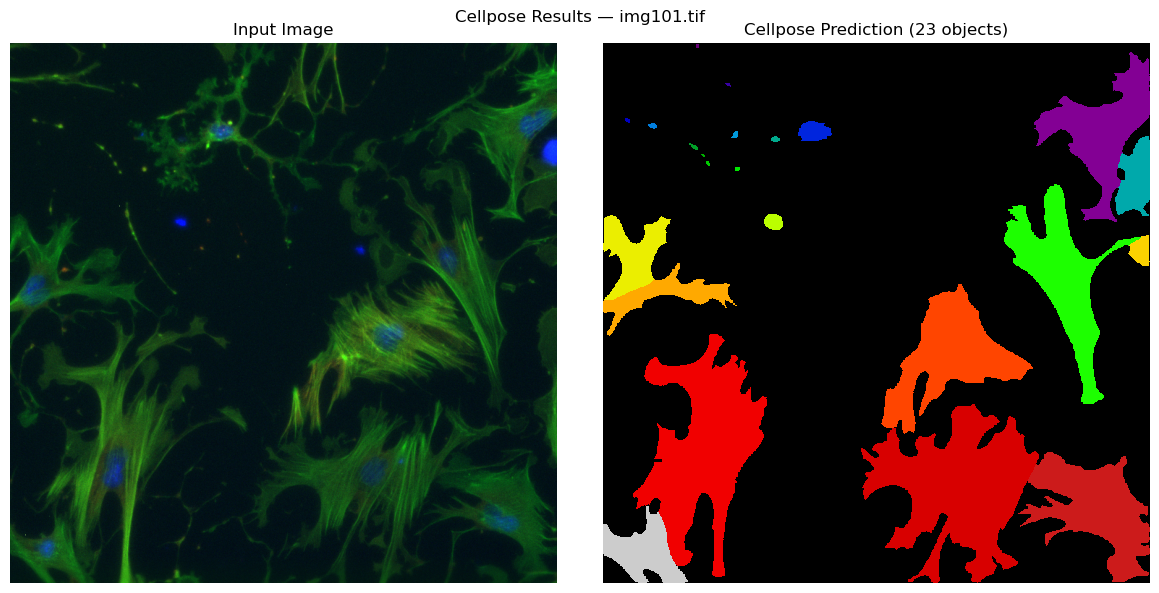

In [17]:
# Try to load an existing annotation for the same image
annotations_dir = project_path / "annotations"
annotation_name = test_images[0].stem + ".tif"
annotation_path = annotations_dir / annotation_name

has_gt = annotation_path.exists()

ncols = 3 if has_gt else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))

axes[0].imshow(test_image/test_image.max(), cmap="gray")
axes[0].set_title("Input Image")
axes[0].axis("off")

if has_gt:
    gt = tifffile.imread(str(annotation_path))
    axes[1].imshow(gt)
    axes[1].set_title(f"Ground Truth ({len(np.unique(gt)) - 1} objects)")
    axes[1].axis("off")
    pred_ax = axes[2]
else:
    pred_ax = axes[1]

pred_ax.imshow(predicted_labels, cmap="nipy_spectral", interpolation="nearest")
pred_ax.set_title(f"Cellpose Prediction ({len(np.unique(predicted_labels)) - 1} objects)")
pred_ax.axis("off")

plt.suptitle(f"Cellpose Results — {test_images[0].name}")
plt.tight_layout()
plt.show()

## 9. Overlay — Input with Prediction Contours

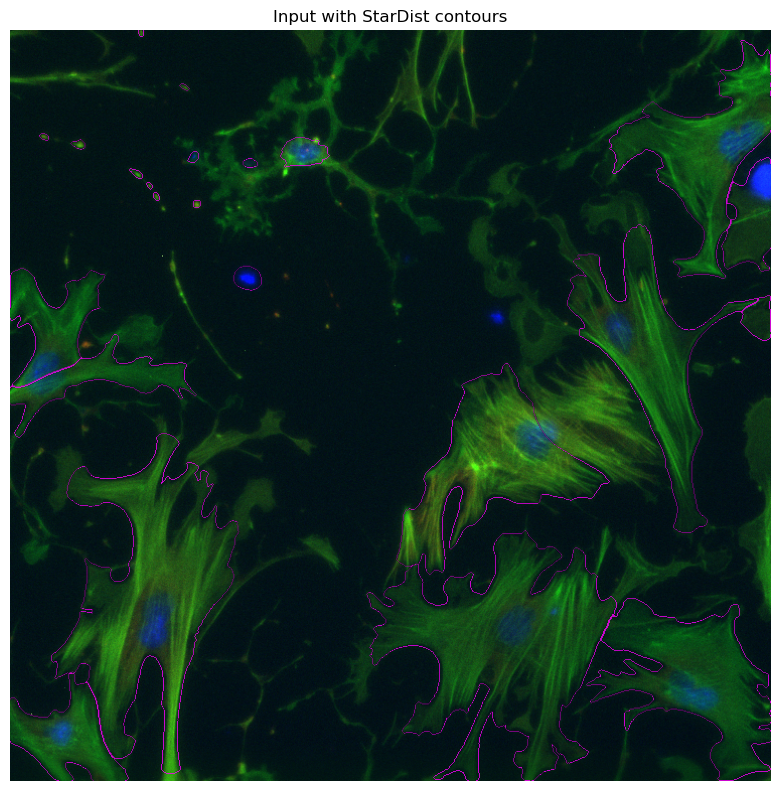

In [19]:
from skimage.segmentation import find_boundaries

boundaries = find_boundaries(predicted_labels, mode="outer")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test_image/test_image.max(), cmap="gray")
ax.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="spring", alpha=0.8)
ax.set_title("Input with StarDist contours")
ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

| Step | What happened |
|------|---------------|
| **Setup** | Pointed to `tests/test_images/nuclei/` — labels already on disk |
| **Patches** | `generate_patches_from_labels` augmented 3 label crops × 200 = 600 patches |
| **Train** | `StardistSegmenter.train()` → Config2D + StarDist2D, 20 epochs |
| **Predict** | `segmenter.segment(image)` using the just-trained custom model |
| **Visualise** | Side-by-side comparison + boundary overlay |